# 🌳 Decision Trees - Complete Learning Guide

## Overview
Decision Trees are versatile supervised learning algorithms that make predictions by learning simple decision rules from data. They're interpretable, work with both classification and regression, and form the basis for powerful ensemble methods.

## Key Topics Covered:
1. **Tree Structure** - Nodes, leaves, and branches
2. **Information Gain** - Entropy and Gini impurity
3. **Tree Construction** - How trees learn
4. **Splitting Criteria** - Information Gain vs Gini
5. **Overfitting & Pruning** - Controlling tree depth
6. **Feature Importance** - Understanding decisions
7. **Real-world Applications** - Practical examples
8. **Hyperparameter Tuning** - max_depth, min_samples_leaf, etc.

---

## References:
- [scikit-learn Decision Trees Documentation](https://scikit-learn.org/stable/modules/tree.html)
- [Decision Tree Pruning](https://en.wikipedia.org/wiki/Decision_tree_pruning)
- [CART Algorithm](https://en.wikipedia.org/wiki/Decision_tree_learning)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report,
    mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🌳 Section 2: Decision Tree Fundamentals

### Tree Structure:
- **Root Node**: Starting point with entire dataset
- **Internal Nodes**: Decision nodes that split the data
- **Leaf Nodes**: Final predictions
- **Branches**: Connections representing decisions

### How Decision Trees Learn:
1. Start with entire dataset at root
2. Find best feature to split (max information gain)
3. Split data into subsets
4. Recursively repeat for each subset
5. Stop when stopping criterion met


🌳 EXAMPLE 1: Simple Decision Tree on Iris Dataset

✅ Model Performance:
  Accuracy: 0.8333
  Tree Depth: 3
  Number of Leaves: 8


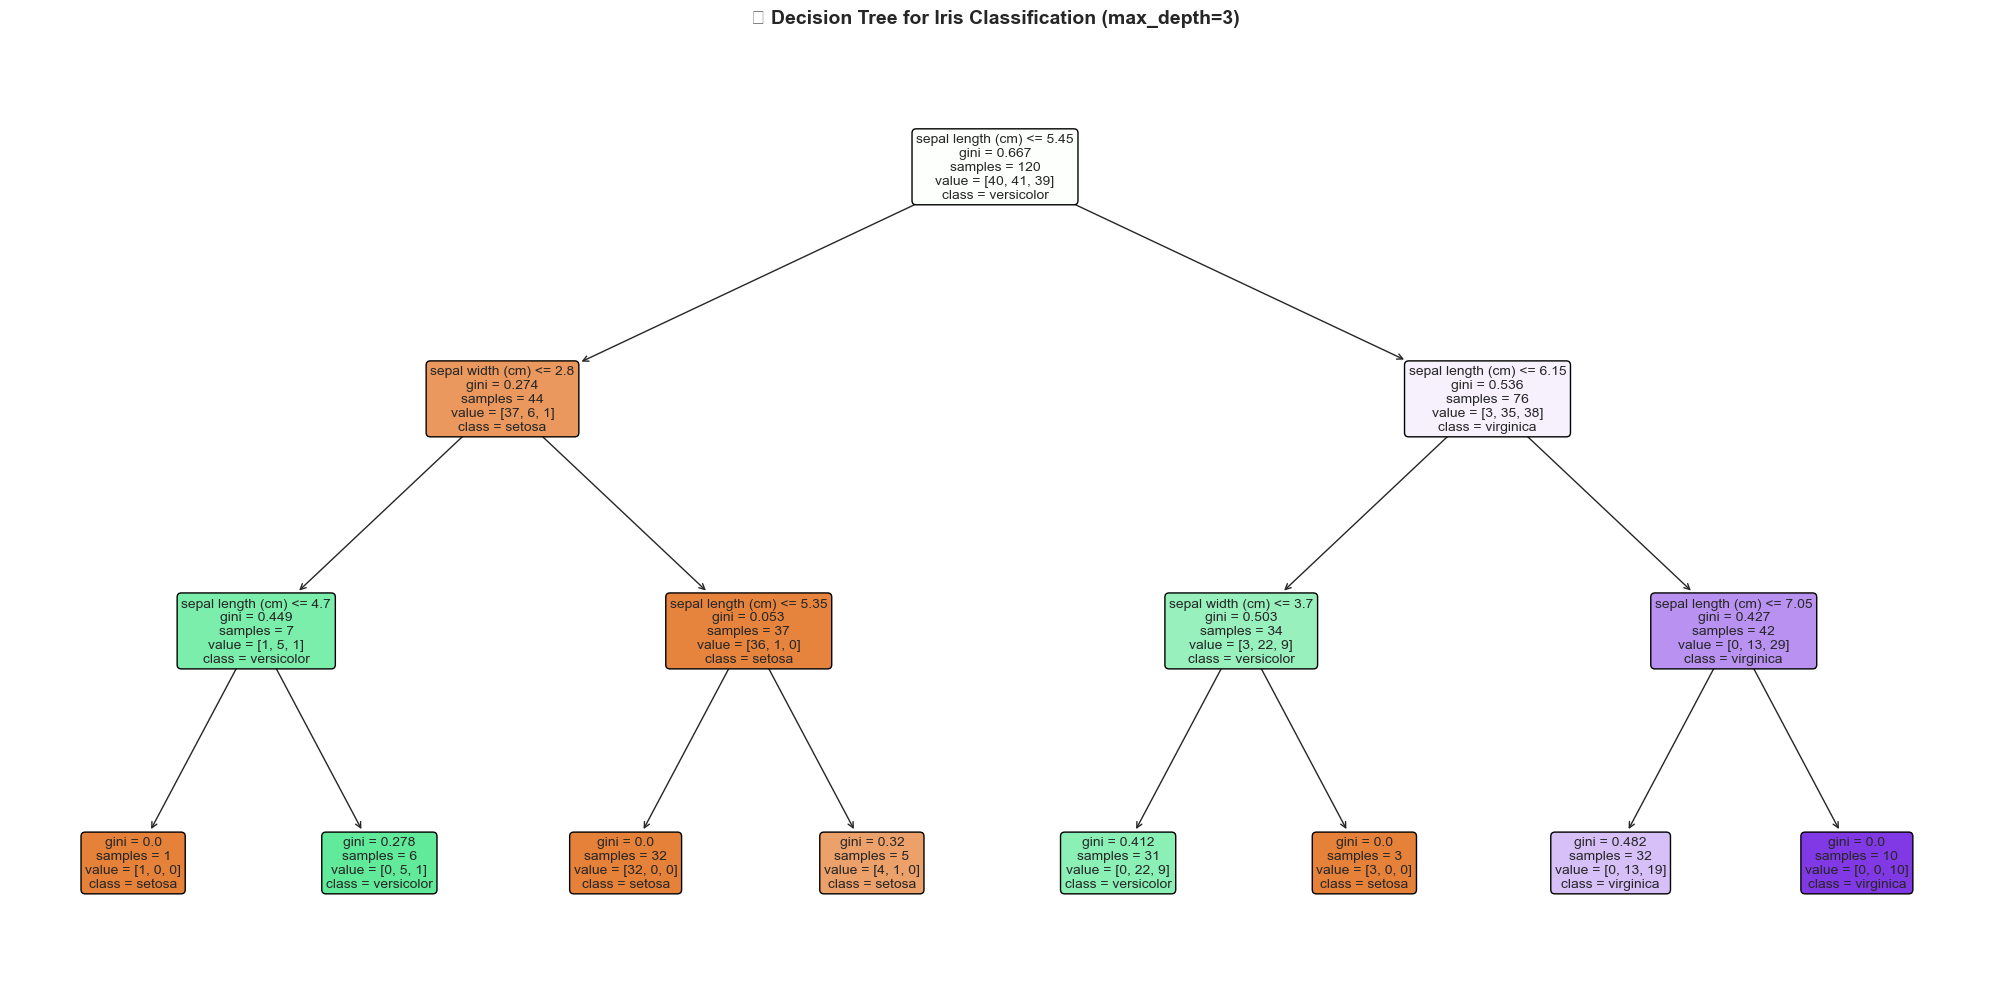


📋 Decision Tree Rules (Text Format):
|--- sepal length (cm) <= 5.45
|   |--- sepal width (cm) <= 2.80
|   |   |--- sepal length (cm) <= 4.70
|   |   |   |--- class: 0
|   |   |--- sepal length (cm) >  4.70
|   |   |   |--- class: 1
|   |--- sepal width (cm) >  2.80
|   |   |--- sepal length (cm) <= 5.35
|   |   |   |--- class: 0
|   |   |--- sepal length (cm) >  5.35
|   |   |   |--- class: 0
|--- sepal length (cm) >  5.45
|   |--- sepal length (cm) <= 6.15
|   |   |--- sepal width (cm) <= 3.70
|   |   |   |--- class: 1
|   |   |--- sepal width (cm) >  3.70
|   |   |   |--- class: 0
|   |--- sepal length (cm) >  6.15
|   |   |--- sepal length (cm) <= 7.05
|   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  7.05
|   |   |   |--- class: 2



In [2]:
# Example 1: Simple Decision Tree Visualization
print("\n" + "="*70)
print("🌳 EXAMPLE 1: Simple Decision Tree on Iris Dataset")
print("="*70)

# Load Iris dataset
iris = load_iris()
X_iris = iris.data[:, :2]  # Use first 2 features
y_iris = iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Train decision tree with limited depth
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_iris, y_train_iris)

# Predictions
y_pred = dt.predict(X_test_iris)
accuracy = accuracy_score(y_test_iris, y_pred)

print(f"\n✅ Model Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Tree Depth: {dt.get_depth()}")
print(f"  Number of Leaves: {dt.get_n_leaves()}")

# Visualize tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=iris.feature_names[:2], class_names=iris.target_names,
          filled=True, ax=ax, fontsize=10, rounded=True)
ax.set_title('🌳 Decision Tree for Iris Classification (max_depth=3)', 
            fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print tree rules
print(f"\n📋 Decision Tree Rules (Text Format):")
print(export_text(dt, feature_names=list(iris.feature_names[:2])))

## 📊 Section 3: Information Gain & Splitting Criteria

### Splitting Criteria:
- **Gini Impurity**: Measures how often a randomly chosen element would be incorrect
- **Entropy (Information Gain)**: Measures disorder/unpredictability

### Formula:
- **Gini**: G = 1 - Σ(p_i)²
- **Entropy**: H = -Σ(p_i * log2(p_i))

Both measure impurity - lower is better (pure = all same class).


📊 EXAMPLE 2: Gini Impurity vs Entropy

✅ Performance Comparison:
  Gini Criterion:    0.9474
  Entropy Criterion: 0.9474
  Difference:        0.0000


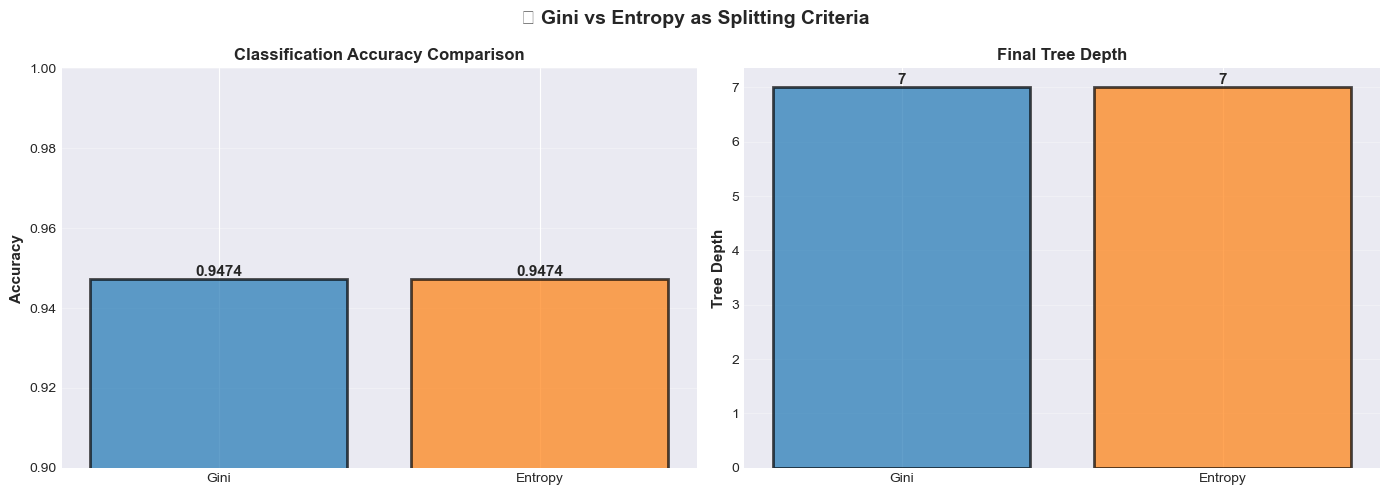

In [3]:
# Example 2: Gini vs Entropy
print("\n" + "="*70)
print("📊 EXAMPLE 2: Gini Impurity vs Entropy")
print("="*70)

# Load breast cancer dataset
cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target

# Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Train trees with different criteria
dt_gini = DecisionTreeClassifier(max_depth=15, criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(max_depth=15, criterion='entropy', random_state=42)

dt_gini.fit(X_train_cancer, y_train_cancer)
dt_entropy.fit(X_train_cancer, y_train_cancer)

# Predictions
y_pred_gini = dt_gini.predict(X_test_cancer)
y_pred_entropy = dt_entropy.predict(X_test_cancer)

acc_gini = accuracy_score(y_test_cancer, y_pred_gini)
acc_entropy = accuracy_score(y_test_cancer, y_pred_entropy)

print(f"\n✅ Performance Comparison:")
print(f"  Gini Criterion:    {acc_gini:.4f}")
print(f"  Entropy Criterion: {acc_entropy:.4f}")
print(f"  Difference:        {abs(acc_gini - acc_entropy):.4f}")

# Visualize impurity values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Gini vs Entropy as Splitting Criteria', fontsize=14, fontweight='bold')

# Distribution
criteria = ['Gini', 'Entropy']
accuracies = [acc_gini, acc_entropy]
colors = ['#1f77b4', '#ff7f0e']

ax = axes[0]
bars = ax.bar(criteria, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Classification Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0.9, 1.0])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Tree depths comparison
ax = axes[1]
depths = [dt_gini.get_depth(), dt_entropy.get_depth()]
bars = ax.bar(criteria, depths, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Tree Depth', fontsize=11, fontweight='bold')
ax.set_title('Final Tree Depth', fontsize=12, fontweight='bold')
for bar, depth in zip(bars, depths):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(depth)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🎯 Section 4: Overfitting & Pruning

### The Problem:
- **Deep trees overfit** - Memorize training data noise
- **Shallow trees underfit** - Miss important patterns

### Solutions:
1. **Limit max_depth**: Fewer levels = simpler tree
2. **Minimum samples**: Require minimum samples to split
3. **Minimum leaf size**: Require minimum samples in leaf
4. **Pruning**: Remove branches with little value


🎯 EXAMPLE 3: Impact of max_depth on Overfitting

🌳 Testing different tree depths:
  Depth:  1 -> Train: 0.9209, Test: 0.8947
  Depth:  3 -> Train: 0.9780, Test: 0.9474
  Depth:  6 -> Train: 0.9978, Test: 0.9386
  Depth:  9 -> Train: 1.0000, Test: 0.9474
  Depth:  9 -> Train: 1.0000, Test: 0.9474
  Depth: 12 -> Train: 1.0000, Test: 0.9474
  Depth: 15 -> Train: 1.0000, Test: 0.9474
  Depth: 18 -> Train: 1.0000, Test: 0.9474
  Depth: 12 -> Train: 1.0000, Test: 0.9474
  Depth: 15 -> Train: 1.0000, Test: 0.9474
  Depth: 18 -> Train: 1.0000, Test: 0.9474


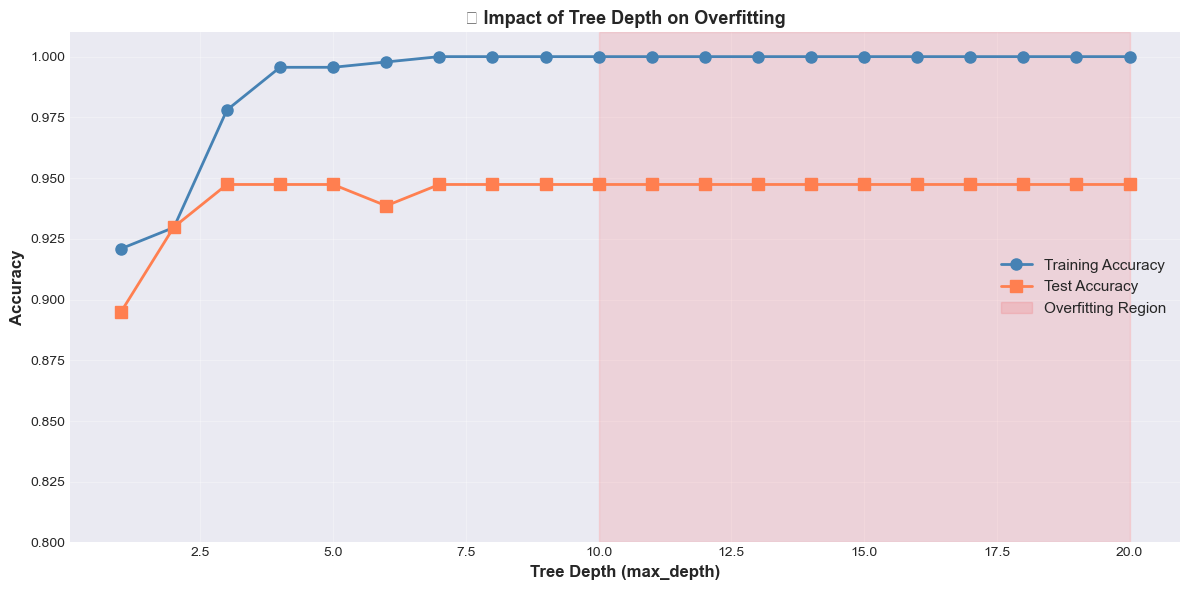


✅ Optimal max_depth: 3 (Test Accuracy: 0.9474)


In [4]:
# Example 3: Effect of max_depth
print("\n" + "="*70)
print("🎯 EXAMPLE 3: Impact of max_depth on Overfitting")
print("="*70)

depths = range(1, 21)
train_accuracies = []
test_accuracies = []

print(f"\n🌳 Testing different tree depths:")
for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_cancer, y_train_cancer)
    
    train_acc = accuracy_score(y_train_cancer, dt_temp.predict(X_train_cancer))
    test_acc = accuracy_score(y_test_cancer, dt_temp.predict(X_test_cancer))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if depth % 3 == 0 or depth == 1:
        print(f"  Depth: {depth:2d} -> Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(depths, train_accuracies, 'o-', linewidth=2, markersize=8,
        label='Training Accuracy', color='steelblue')
ax.plot(depths, test_accuracies, 's-', linewidth=2, markersize=8,
        label='Test Accuracy', color='coral')

# Mark overfitting region
ax.axvspan(10, 20, alpha=0.1, color='red', label='Overfitting Region')

ax.set_xlabel('Tree Depth (max_depth)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('🎯 Impact of Tree Depth on Overfitting', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.8, 1.01])

plt.tight_layout()
plt.show()

# Find optimal depth
optimal_idx = np.argmax(test_accuracies)
optimal_depth = list(depths)[optimal_idx]
print(f"\n✅ Optimal max_depth: {optimal_depth} (Test Accuracy: {test_accuracies[optimal_idx]:.4f})")

## ⭐ Section 5: Feature Importance in Decision Trees

### What is Feature Importance?
- Measures how much each feature contributes to predictions
- Based on information gain at each split
- Higher values = more important for classification


⭐ EXAMPLE 4: Feature Importance Analysis

🎯 Top 15 Most Important Features:
   1. mean concave points       = 0.6914
   2. worst concave points      = 0.0657
   3. mean texture              = 0.0585
   4. worst radius              = 0.0523
   5. worst perimeter           = 0.0515
   6. fractal dimension error   = 0.0186
   7. worst texture             = 0.0174
   8. concave points error      = 0.0159
   9. area error                = 0.0120
  10. worst smoothness          = 0.0092
  11. concavity error           = 0.0063
  12. smoothness error          = 0.0012
  13. mean smoothness           = 0.0000
  14. mean fractal dimension    = 0.0000
  15. mean compactness          = 0.0000


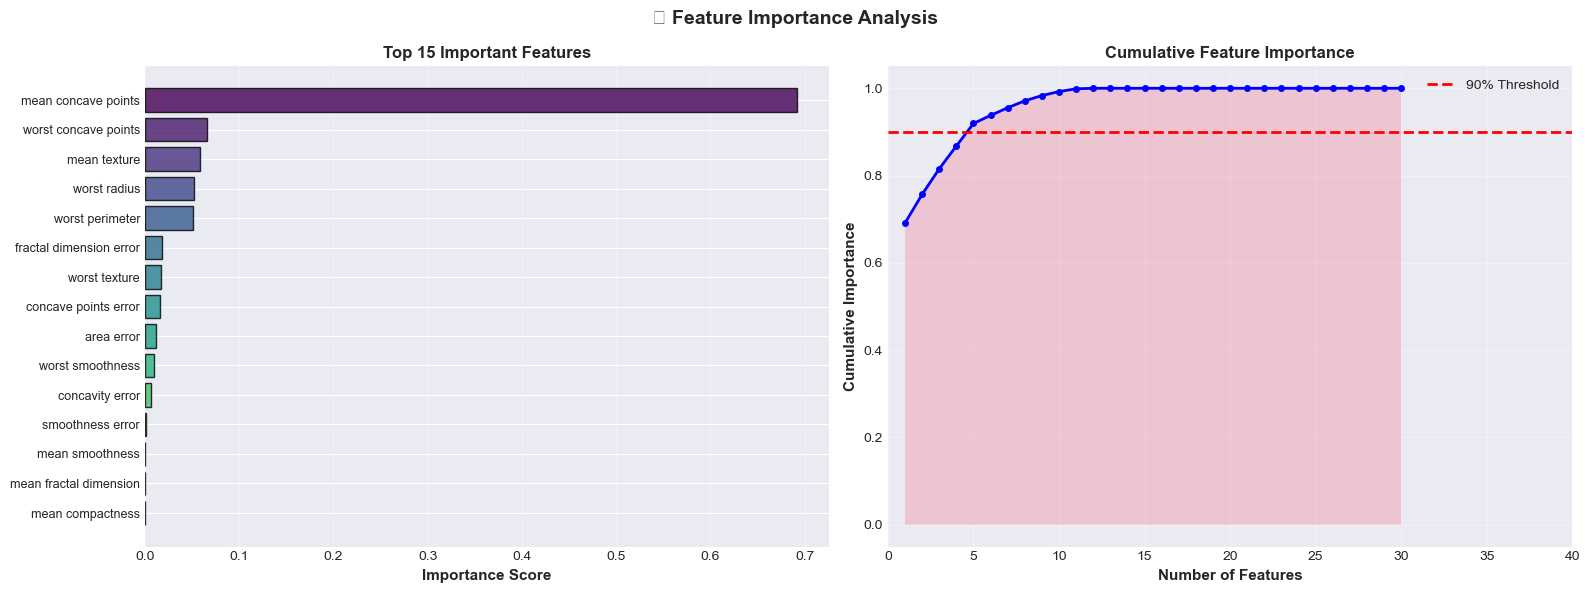


📊 Feature Reduction Potential:
  Features for 90% importance: 5 out of 30
  Potential reduction: 83.3%


In [5]:
# Example 4: Feature Importance
print("\n" + "="*70)
print("⭐ EXAMPLE 4: Feature Importance Analysis")
print("="*70)

# Train optimal tree
dt_optimal = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_optimal.fit(X_train_cancer, y_train_cancer)

# Get feature importances
feature_importance = dt_optimal.feature_importances_
feature_names = cancer_data.feature_names

# Sort by importance
indices = np.argsort(feature_importance)[::-1]

print(f"\n🎯 Top 15 Most Important Features:")
for i, idx in enumerate(indices[:15], 1):
    print(f"  {i:2d}. {feature_names[idx]:25s} = {feature_importance[idx]:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('⭐ Feature Importance Analysis', fontsize=14, fontweight='bold')

# Top 15 features - bar plot
ax = axes[0]
top_15_idx = indices[:15]
top_15_names = [feature_names[i] for i in top_15_idx]
top_15_importance = feature_importance[top_15_idx]

colors_bar = plt.cm.viridis(np.linspace(0, 1, 15))
ax.barh(range(15), top_15_importance, color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels(top_15_names, fontsize=9)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Important Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Cumulative importance
ax = axes[1]
cumsum = np.cumsum(feature_importance[indices])
ax.plot(range(1, len(cumsum) + 1), cumsum, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0.9, color='r', linestyle='--', linewidth=2, label='90% Threshold')
ax.fill_between(range(1, len(cumsum) + 1), cumsum, alpha=0.3)
ax.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
ax.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim([0, 40])

plt.tight_layout()
plt.show()

# Feature reduction insight
n_features_90 = np.argmax(cumsum >= 0.9) + 1
print(f"\n📊 Feature Reduction Potential:")
print(f"  Features for 90% importance: {n_features_90} out of {len(feature_importance)}")
print(f"  Potential reduction: {(1 - n_features_90/len(feature_importance))*100:.1f}%")

## ⚙️ Section 6: Hyperparameter Tuning

### Key Hyperparameters:
- **max_depth**: Maximum tree depth
- **min_samples_split**: Min samples to split a node
- **min_samples_leaf**: Min samples required at leaf
- **max_features**: Features to consider at each split
- **criterion**: Splitting criterion (gini or entropy)

In [6]:
# Example 5: Hyperparameter Tuning
print("\n" + "="*70)
print("⚙️ EXAMPLE 5: Hyperparameter Tuning with GridSearchCV")
print("="*70)

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

total_combos = (len(param_grid['max_depth']) * len(param_grid['min_samples_split']) *
                 len(param_grid['min_samples_leaf']) * len(param_grid['criterion']))

print(f"\n🔍 Parameter Grid:")
print(f"  max_depth: {param_grid['max_depth']}")
print(f"  min_samples_split: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"  criterion: {param_grid['criterion']}")
print(f"  Total combinations: {total_combos}")

print(f"\n⏳ Running GridSearchCV...")
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, n_jobs=-1, verbose=0)
grid_search.fit(X_train_cancer, y_train_cancer)

print(f"\n✅ Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

# Test best model
best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test_cancer)
accuracy_tuned = accuracy_score(y_test_cancer, y_pred_tuned)

print(f"\n📊 Best Model Performance on Test Set:")
print(f"  Accuracy: {accuracy_tuned:.4f}")


⚙️ EXAMPLE 5: Hyperparameter Tuning with GridSearchCV

🔍 Parameter Grid:
  max_depth: [5, 10, 15, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  criterion: ['gini', 'entropy']
  Total combinations: 72

⏳ Running GridSearchCV...

✅ Best Parameters Found:
  criterion: entropy
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 10
  Best CV Score: 0.9473

📊 Best Model Performance on Test Set:
  Accuracy: 0.9561

✅ Best Parameters Found:
  criterion: entropy
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 10
  Best CV Score: 0.9473

📊 Best Model Performance on Test Set:
  Accuracy: 0.9561


## 📈 Section 7: Decision Tree for Regression

Decision Trees can also solve regression problems!


📈 EXAMPLE 6: Decision Tree for Regression


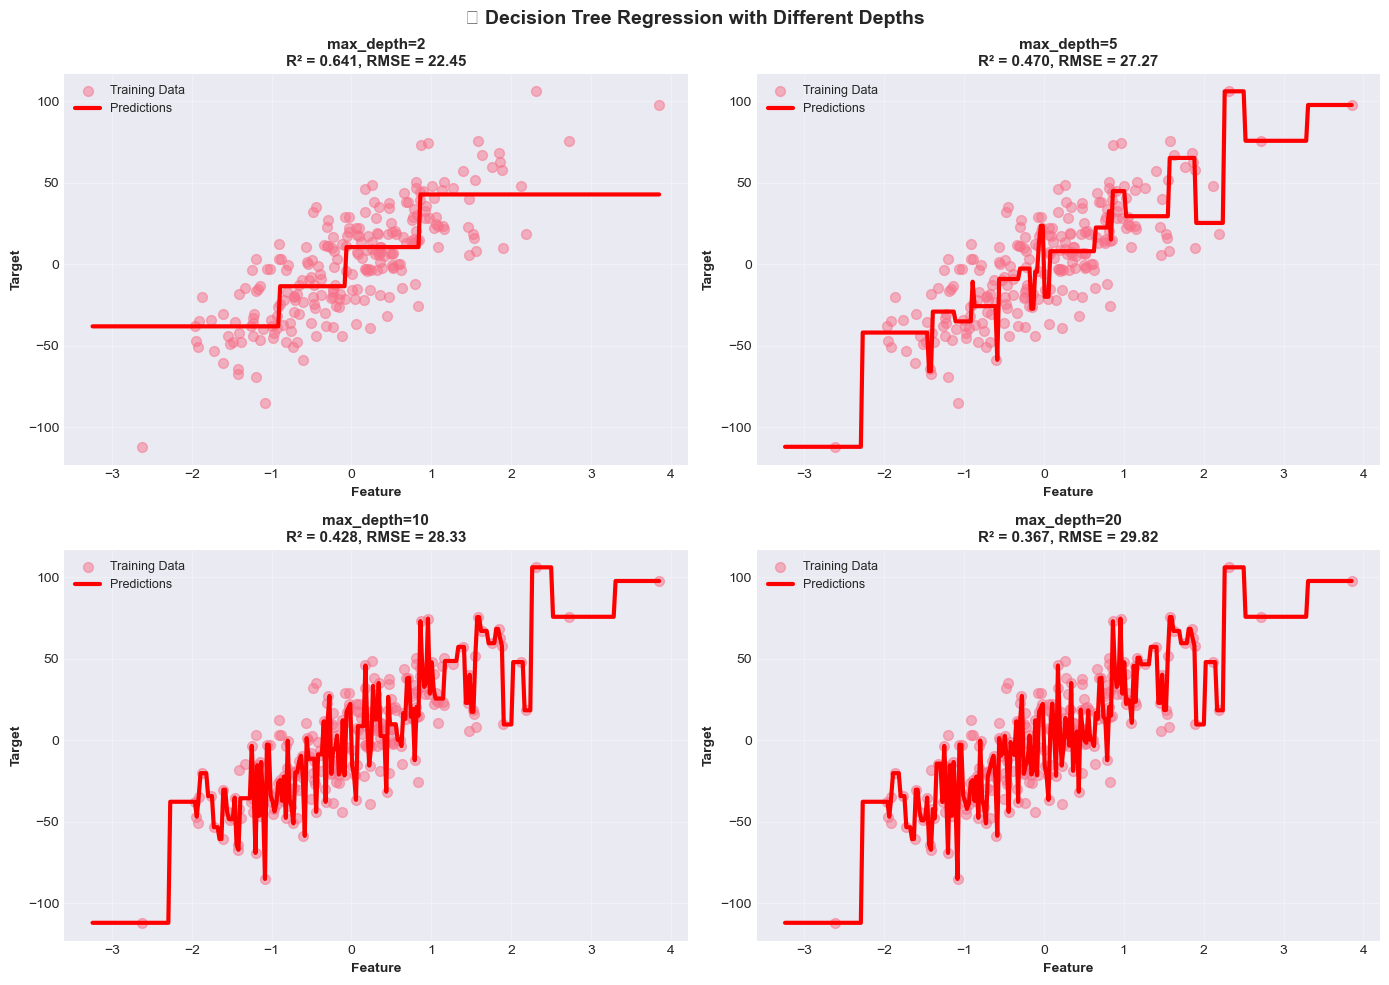


✅ Regression Performance:
  max_depth= 2: R² = 0.6409
  max_depth= 5: R² = 0.4705
  max_depth=10: R² = 0.4284
  max_depth=20: R² = 0.3666


In [7]:
# Example 6: Decision Tree Regression
print("\n" + "="*70)
print("📈 EXAMPLE 6: Decision Tree for Regression")
print("="*70)

# Create regression data
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(n_samples=300, n_features=1, noise=20, random_state=42)

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train trees with different depths
depths = [2, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📈 Decision Tree Regression with Different Depths', fontsize=14, fontweight='bold')

for idx, depth in enumerate(depths):
    ax = axes[idx // 2, idx % 2]
    
    # Train model
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_reg.fit(X_train_reg, y_train_reg)
    
    # Predictions
    y_pred_reg = dt_reg.predict(X_test_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    
    # Plot
    ax.scatter(X_train_reg, y_train_reg, alpha=0.5, label='Training Data', s=50)
    
    # Prediction line
    X_line = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)
    y_line = dt_reg.predict(X_line)
    ax.plot(X_line, y_line, 'r-', linewidth=3, label='Predictions', zorder=10)
    
    ax.set_xlabel('Feature', fontsize=10, fontweight='bold')
    ax.set_ylabel('Target', fontsize=10, fontweight='bold')
    ax.set_title(f'max_depth={depth}\nR² = {r2:.3f}, RMSE = {rmse:.2f}', 
                fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Regression Performance:")
for depth in depths:
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_reg.fit(X_train_reg, y_train_reg)
    y_pred = dt_reg.predict(X_test_reg)
    r2 = r2_score(y_test_reg, y_pred)
    print(f"  max_depth={depth:2d}: R² = {r2:.4f}")

## 📋 Section 8: Decision Tree Advantages & Disadvantages

### ✅ Advantages:
1. **Highly interpretable** - Easy to understand decisions
2. **No scaling needed** - Works with raw features
3. **Handles non-linearity** - Learns non-linear patterns
4. **Feature importance** - Built-in feature ranking
5. **Works with categorical data** - No encoding needed
6. **Classification and regression** - Versatile
7. **Fast prediction** - Linear in tree depth

### ❌ Disadvantages:
1. **Prone to overfitting** - Needs careful pruning
2. **Unstable** - Small data changes = big tree changes
3. **Biased toward high-cardinality features** - May favor certain features
4. **Not great at complex patterns** - Single trees are weak learners
5. **Requires balanced data** - Works poorly with imbalanced classes
6. **Greedy algorithm** - Doesn't guarantee optimal tree

### When to Use:
- When interpretability is critical
- For quick baseline models
- When you need feature importance
- For mixed data types (categorical + numerical)
- As base learner in ensemble methods

In [8]:
# Example 7: Summary & Best Practices
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS & BEST PRACTICES")
print("="*70)

best_practices = [
    "Always limit max_depth to prevent overfitting",
    "Use min_samples_leaf to enforce minimum node size",
    "Validate with cross-validation, not just train/test split",
    "Check feature importance for insights",
    "Decision trees are building blocks for Random Forest/Boosting",
    "Start simple: use shallow trees first",
    "Use Gini for faster training, Entropy for more principled approach",
    "Pre-prune (limit growth) is better than post-prune",
    "Trees handle missing values poorly - impute first",
    "For ensemble: Single trees are weak, but together they're strong!"
]

for i, practice in enumerate(best_practices, 1):
    print(f"\n{i:2d}. {practice}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS & BEST PRACTICES

 1. Always limit max_depth to prevent overfitting

 2. Use min_samples_leaf to enforce minimum node size

 3. Validate with cross-validation, not just train/test split

 4. Check feature importance for insights

 5. Decision trees are building blocks for Random Forest/Boosting

 6. Start simple: use shallow trees first

 7. Use Gini for faster training, Entropy for more principled approach

 8. Pre-prune (limit growth) is better than post-prune

 9. Trees handle missing values poorly - impute first

10. For ensemble: Single trees are weak, but together they're strong!

